<center> Energy

### Libraries

In [113]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

In [192]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

### Custom Functions

In [559]:
# Reference: https://www.kaggle.com/code/selahattinsanli/visualizing-missing-data
# Check for missing values
def check_missing_val(dataframe, ax=np.nan):
 if pd.isnull(ax) == False:   
    sns.histplot(
        data = dataframe.isnull().melt(value_name='missing'),
        y='variable',
        hue='missing',
        multiple = 'fill',
        ax=ax
    )
 else:
    sns.histplot(
        data = dataframe.isnull().melt(value_name='missing'),
        y='variable',
        hue='missing',
        multiple = 'fill'
    )

def transform_to_columns(dataset, row, col, values):
    dataset_melted = pd.melt(dataset, id_vars=[row, col], value_vars=[values])
    dataset_melted = dataset_melted.set_index([row, col])['value'].unstack()
    dataset_melted.reset_index(inplace=True)
    return dataset_melted

### Datasets

In [393]:
# Import Datasets
energy_import_df = pd.read_csv('./Datasets/03-net-energy-import-ie.csv')
gross_energy_df = pd.read_csv('./Datasets/05-gross-energy-ie.csv')
energy_prod_df = pd.read_csv('./Datasets/02-primary-energy-prod-ie.csv')

energy_import_df.head()

,STATISTIC,Statistic Label,C02404V02898,Fuel Type,TLIST(A1),Year,UNIT,VALUE
0,SEI03,Net Energy Imports,9,Net imports,1990,1990,ktoe,6992
1,SEI03,Net Energy Imports,9,Net imports,1991,1991,ktoe,6816
2,SEI03,Net Energy Imports,9,Net imports,1992,1992,ktoe,6657
3,SEI03,Net Energy Imports,9,Net imports,1993,1993,ktoe,6970
4,SEI03,Net Energy Imports,9,Net imports,1994,1994,ktoe,7068


In [395]:
gross_energy_df.head()

,STATISTIC,Statistic Label,C02405V02899,Energy Supply and Consumption,TLIST(A1),Year,UNIT,VALUE
0,SEI05,Gross Energy Consumption,6,Primary energy supply including non energy,1990,1990,ktoe,10131
1,SEI05,Gross Energy Consumption,6,Primary energy supply including non energy,1991,1991,ktoe,10341
2,SEI05,Gross Energy Consumption,6,Primary energy supply including non energy,1992,1992,ktoe,10334
3,SEI05,Gross Energy Consumption,6,Primary energy supply including non energy,1993,1993,ktoe,10511
4,SEI05,Gross Energy Consumption,6,Primary energy supply including non energy,1994,1994,ktoe,10997


In [397]:
energy_prod_df.head()

,STATISTIC,Statistic Label,C02404V02898,Fuel Type,TLIST(A1),Year,UNIT,VALUE
0,SEI02,Primary Energy Production,8,Sum of all indigenous production,1990,1990,ktoe,3471.0
1,SEI02,Primary Energy Production,8,Sum of all indigenous production,1991,1991,ktoe,3291.0
2,SEI02,Primary Energy Production,8,Sum of all indigenous production,1992,1992,ktoe,3086.0
3,SEI02,Primary Energy Production,8,Sum of all indigenous production,1993,1993,ktoe,3456.0
4,SEI02,Primary Energy Production,8,Sum of all indigenous production,1994,1994,ktoe,3565.0


## Data Preparation

In [400]:
energy_import_df.info(), gross_energy_df.info(), energy_prod_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   STATISTIC        782 non-null    object
 1   Statistic Label  782 non-null    object
 2   C02404V02898     782 non-null    int64 
 3   Fuel Type        782 non-null    object
 4   TLIST(A1)        782 non-null    int64 
 5   Year             782 non-null    int64 
 6   UNIT             782 non-null    object
 7   VALUE            782 non-null    int64 
dtypes: int64(4), object(4)
memory usage: 49.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   STATISTIC                      238 non-null    object
 1   Statistic Label                238 non-null    object
 2   C02405V02899                   238 non-null    int

(None, None, None)

In [402]:
energy_import_df.nunique(), gross_energy_df.nunique(), energy_prod_df.nunique()

(STATISTIC            1
 Statistic Label      1
 C02404V02898        23
 Fuel Type           23
 TLIST(A1)           34
 Year                34
 UNIT                 1
 VALUE              504
 dtype: int64,
 STATISTIC                          1
 Statistic Label                    1
 C02405V02899                       7
 Energy Supply and Consumption      7
 TLIST(A1)                         34
 Year                              34
 UNIT                               1
 VALUE                            216
 dtype: int64,
 STATISTIC            1
 Statistic Label      1
 C02404V02898        14
 Fuel Type           14
 TLIST(A1)           34
 Year                34
 UNIT                 1
 VALUE              242
 dtype: int64)

In [404]:
energy_import_df.drop(columns=['STATISTIC', 'Statistic Label', 'TLIST(A1)', 'C02404V02898','UNIT'], inplace=True)
energy_import_df

,Fuel Type,Year,VALUE
0,Net imports,1990,6992
1,Net imports,1991,6816
2,Net imports,1992,6657
3,Net imports,1993,6970
4,Net imports,1994,7068
...,...,...,...
777,Electricity,2019,55
778,Electricity,2020,-13
779,Electricity,2021,137
780,Electricity,2022,22


In [406]:
gross_energy_df.drop(columns=['STATISTIC', 'Statistic Label', 'TLIST(A1)', 'C02405V02899','UNIT'], inplace=True)
gross_energy_df

,Energy Supply and Consumption,Year,VALUE
0,Primary energy supply including non energy,1990,10131
1,Primary energy supply including non energy,1991,10341
2,Primary energy supply including non energy,1992,10334
3,Primary energy supply including non energy,1993,10511
4,Primary energy supply including non energy,1994,10997
...,...,...,...
233,Final energy consumption,2019,12429
234,Final energy consumption,2020,11243
235,Final energy consumption,2021,11499
236,Final energy consumption,2022,12008


In [408]:
energy_prod_df.drop(columns=['STATISTIC', 'Statistic Label', 'TLIST(A1)', 'C02404V02898','UNIT'], inplace=True)
energy_prod_df

,Fuel Type,Year,VALUE
0,Sum of all indigenous production,1990,3471.0
1,Sum of all indigenous production,1991,3291.0
2,Sum of all indigenous production,1992,3086.0
3,Sum of all indigenous production,1993,3456.0
4,Sum of all indigenous production,1994,3565.0
...,...,...,...
471,Non renewable waste,2019,145.0
472,Non renewable waste,2020,147.0
473,Non renewable waste,2021,143.0
474,Non renewable waste,2022,148.0


In [410]:
energy_import_df['Fuel Type'].value_counts()

Fuel Type
Net imports                           34
Jet kerosene                          34
Non renewable waste                   34
Liquid Biofuel                        34
Biomass                               34
Sum of all renewable energies         34
Natural gas                           34
Petroleum coke                        34
Gasoil/diesel/DERV                    34
LPG                                   34
Fuel oil                              34
Kerosene                              34
Sum of all coal products              34
Gasoline                              34
Refinery gas                          34
Refinery feedstock                    34
Crude oil                             34
Sum of all petroleum products         34
Briquettes                            34
Lignite                               34
Anthracite and manufactured ovoids    34
Bituminous coal                       34
Electricity                           34
Name: count, dtype: int64

In [412]:
gross_energy_df['Energy Supply and Consumption'].value_counts()

Energy Supply and Consumption
Primary energy supply including non energy         34
Primary energy requirement excluding non energy    34
Sum of all transformation input                    34
Sum of all exchanges and transfers                 34
Own use and distribution losses                    34
Non-energy consumption                             34
Final energy consumption                           34
Name: count, dtype: int64

In [414]:
energy_prod_df['Fuel Type'].value_counts()

Fuel Type
Sum of all indigenous production    34
Sum of all coal products            34
Sum of all peat products            34
Natural gas                         34
Sum of all renewable energies       34
Hydro                               34
Wind                                34
Biomass                             34
Landfill gas                        34
Biogas                              34
Liquid Biofuel                      34
Solar                               34
Geothermal                          34
Non renewable waste                 34
Name: count, dtype: int64

#### Check for Missing Values

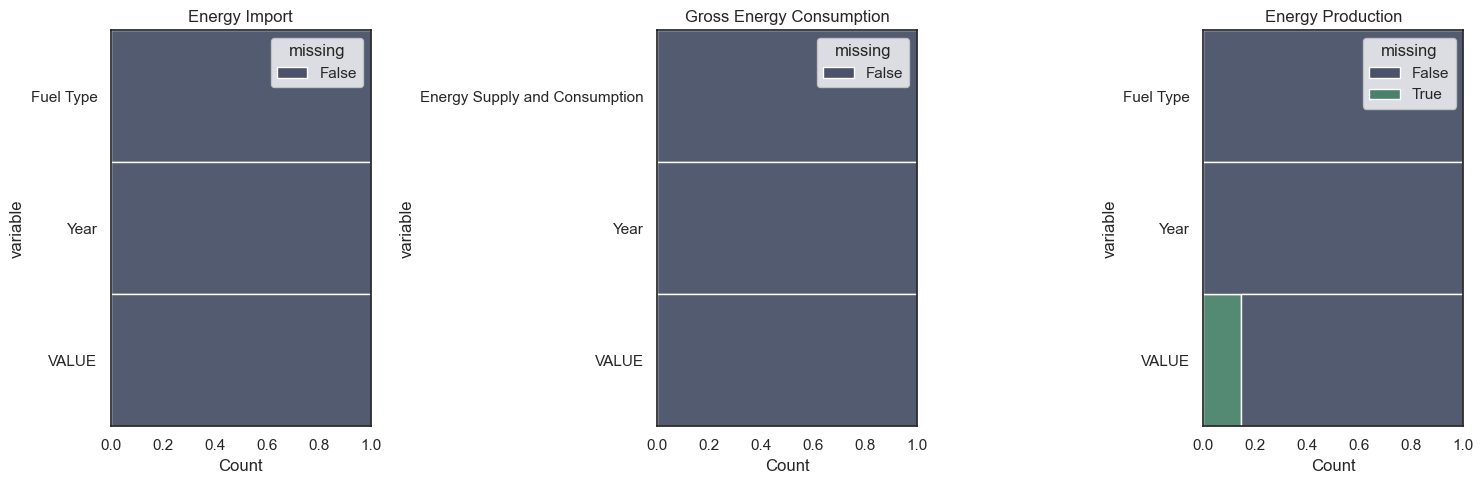

In [417]:
# Set figure pallete
sns.set_palette('cubehelix')

# Create 1 row, 3 column subplot grid
fig, ax = plt.subplots(1, 3, figsize=(15, 5))  # Made it wider to fit 3 plots better

check_missing_val(energy_import_df, ax[0])  # Assuming this function is defined to use ax[]
ax[0].set_title('Energy Import')

check_missing_val(gross_energy_df, ax[1])
ax[1].set_title('Gross Energy Consumption')

check_missing_val(energy_prod_df, ax[2])
ax[2].set_title('Energy Production')


plt.tight_layout()
plt.show()

In [471]:
energy_import_melted = transform_to_columns(energy_import_df, 'Year', 'Fuel Type', 'VALUE')

cols = energy_import_melted.columns[energy_import_melted.columns.str.startswith('Sum')]
cols = list(cols)          # Now it's a regular Python list
cols.append('Year')        # This works fine now

energy_import_melted=energy_import_melted[cols]
energy_import_melted['total_energy_import'] = energy_import_melted['Sum of all coal products'] + energy_import_melted['Sum of all petroleum products'] + energy_import_melted['Sum of all renewable energies']
energy_import_melted.rename(columns={'Year':'Year',
                                     'Sum of all coal products': 'import_coal_products',
                                     'Sum of all petroleum products':'import_petroleum_products',
                                     'Sum of all renewable energies': 'import_renewable_energies'}, inplace=True)
energy_import_melted.head()

Fuel Type,import_coal_products,import_petroleum_products,import_renewable_energies,Year,total_energy_import
0,1992,5004,0,1990,6996
1,2004,4817,0,1991,6821
2,1948,4713,0,1992,6661
3,1859,5113,0,1993,6972
4,1543,5527,0,1994,7070
5,1886,5753,0,1995,7639
6,1789,6108,0,1996,7897
7,1951,6733,0,1997,8684
8,1852,7525,0,1998,9377
9,1530,8412,0,1999,9942


In [595]:
gross_energy_melted = transform_to_columns(gross_energy_df, 'Year', 'Energy Supply and Consumption','VALUE')
gross_energy_melted=gross_energy_melted[['Year','Final energy consumption', 'Primary energy requirement excluding non energy']]
gross_energy_melted['energy_loss_percent'] = ((gross_energy_melted['Primary energy requirement excluding non energy'] - gross_energy_melted['Final energy consumption'])/(gross_energy_melted['Primary energy requirement excluding non energy'])*100)
gross_energy_melted.rename(columns={
    'Final energy consumption':'final_energy_consumption',
    'Primary energy requirement excluding non energy':'primary_energy_req_excluding_non_energy'
    },
    inplace=True)
gross_energy_melted

Energy Supply and Consumption,Year,final_energy_consumption,primary_energy_req_excluding_non_energy,energy_loss_percent
0,1990,7249,9515,23.815029
1,1991,7448,9703,23.240235
2,1992,7325,9717,24.616651
3,1993,7591,9954,23.739200
4,1994,7861,10389,24.333430
5,1995,7979,10581,24.591248
6,1996,8335,11201,25.587001
7,1997,8646,11704,26.127820
8,1998,9356,12561,25.515484
9,1999,9944,13321,25.350950


In [523]:
energy_prod_melted=transform_to_columns(energy_prod_df, 'Year', 'Fuel Type','VALUE')
energy_prod_melted.fillna(value=0, inplace=True)

cols = energy_prod_melted.columns[energy_prod_melted.columns.str.startswith('Sum')]
cols = list(cols)       
cols.append('Year') 

energy_prod_melted=energy_prod_melted[cols]
energy_prod_melted.rename(columns={
    'Sum of all coal products':'prod_coal_products',
    'Sum of all indigenous production':'prod_indegenous_production',
    'Sum of all peat products':'prod_peat_products',
    'Sum of all renewable energies':'prod_renewable_energies'},
    inplace= True)
energy_prod_melted['total_produced_energy'] = energy_prod_melted.prod_coal_products + energy_prod_melted.prod_indegenous_production + energy_prod_melted.prod_peat_products + energy_prod_melted.prod_renewable_energies 
energy_prod_melted

Fuel Type,prod_coal_products,prod_indegenous_production,prod_peat_products,prod_renewable_energies,Year,total_produced_energy
0,16.0,3471.0,1411.0,168.0,1990,5066.0
1,1.0,3291.0,1200.0,168.0,1991,4660.0
2,1.0,3086.0,1021.0,162.0,1992,4270.0
3,1.0,3456.0,1134.0,161.0,1993,4752.0
4,1.0,3565.0,1192.0,174.0,1994,4932.0
5,1.0,4105.0,1697.0,155.0,1995,5958.0
6,0.0,3544.0,1203.0,169.0,1996,4916.0
7,0.0,2857.0,766.0,181.0,1997,3804.0
8,0.0,2463.0,822.0,231.0,1998,3516.0
9,0.0,2462.0,1135.0,222.0,1999,3819.0


In [599]:
ie_energy_summary_df = pd.merge(energy_import_melted, energy_prod_melted,on='Year', how='inner')
ie_energy_summary_df = pd.merge(ie_energy_summary_df, gross_energy_melted, on='Year', how='inner')

ie_energy_summary_df=ie_energy_summary_df[['Year','import_coal_products', 'import_petroleum_products',
       'import_renewable_energies', 'total_energy_import',
       'prod_coal_products', 'prod_indegenous_production',
       'prod_peat_products', 'prod_renewable_energies',
       'total_produced_energy', 'final_energy_consumption',
       'primary_energy_req_excluding_non_energy', 'energy_loss_percent']]
ie_energy_summary_df

,Year,import_coal_products,import_petroleum_products,import_renewable_energies,total_energy_import,prod_coal_products,prod_indegenous_production,prod_peat_products,prod_renewable_energies,total_produced_energy,final_energy_consumption,primary_energy_req_excluding_non_energy,energy_loss_percent
0,1990,1992,5004,0,6996,16.0,3471.0,1411.0,168.0,5066.0,7249,9515,23.815029
1,1991,2004,4817,0,6821,1.0,3291.0,1200.0,168.0,4660.0,7448,9703,23.240235
2,1992,1948,4713,0,6661,1.0,3086.0,1021.0,162.0,4270.0,7325,9717,24.616651
3,1993,1859,5113,0,6972,1.0,3456.0,1134.0,161.0,4752.0,7591,9954,23.739200
4,1994,1543,5527,0,7070,1.0,3565.0,1192.0,174.0,4932.0,7861,10389,24.333430
5,1995,1886,5753,0,7639,1.0,4105.0,1697.0,155.0,5958.0,7979,10581,24.591248
6,1996,1789,6108,0,7897,0.0,3544.0,1203.0,169.0,4916.0,8335,11201,25.587001
7,1997,1951,6733,0,8684,0.0,2857.0,766.0,181.0,3804.0,8646,11704,26.127820
8,1998,1852,7525,0,9377,0.0,2463.0,822.0,231.0,3516.0,9356,12561,25.515484
9,1999,1530,8412,0,9942,0.0,2462.0,1135.0,222.0,3819.0,9944,13321,25.350950


# Data Visualization

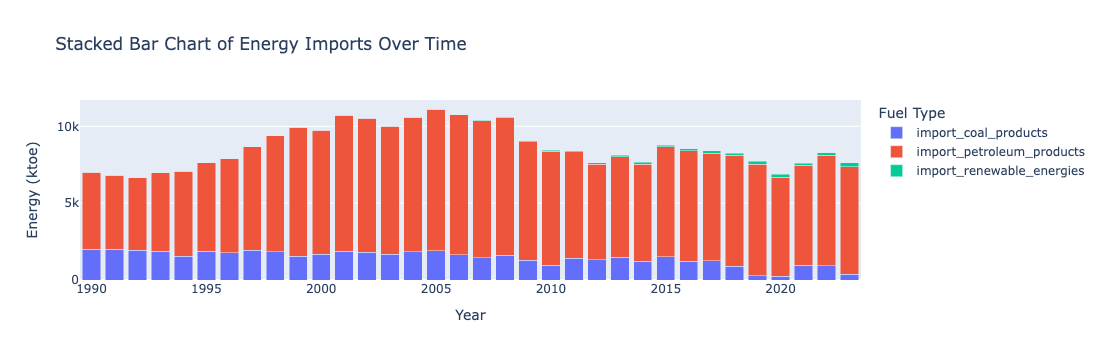

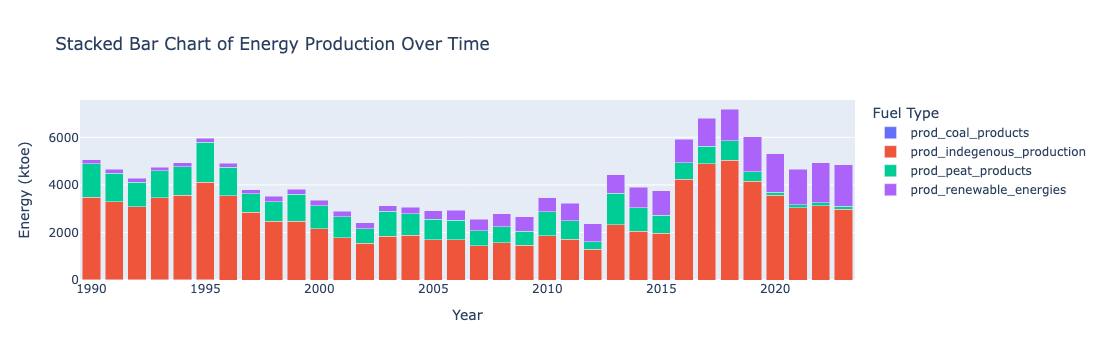

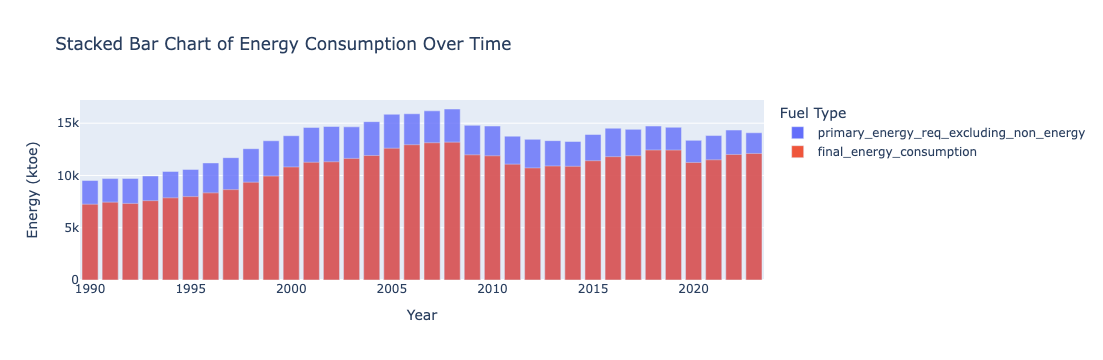

In [728]:
df_melted = ie_energy_summary_df.melt(id_vars='Year', value_vars=['import_coal_products', 'import_petroleum_products', 'import_renewable_energies'],
                    var_name='Fuel Type', value_name='Energy (ktoe)')

fig = px.bar(
    df_melted,
    x='Year',
    y='Energy (ktoe)',
    color='Fuel Type',
    title='Stacked Bar Chart of Energy Imports Over Time',
    barmode='stack'
)
fig.show()


df_melted = ie_energy_summary_df.melt(id_vars='Year', value_vars=['prod_coal_products', 'prod_indegenous_production', 'prod_peat_products', 'prod_renewable_energies' ],
                    var_name='Fuel Type', value_name='Energy (ktoe)')

fig = px.bar(
    df_melted,
    x='Year',
    y='Energy (ktoe)',
    color='Fuel Type',
    title='Stacked Bar Chart of Energy Production Over Time',
    barmode='stack'
)

fig.show()


df_melted = ie_energy_summary_df.melt(id_vars='Year', value_vars=['primary_energy_req_excluding_non_energy', 'final_energy_consumption'],
                    var_name='Fuel Type', value_name='Energy (ktoe)')

fig = px.bar(
    df_melted,
    x='Year',
    y='Energy (ktoe)',
    color='Fuel Type',
    title='Stacked Bar Chart of Energy Consumption Over Time',
    barmode='overlay',
    opacity=0.8
)

fig.show()

# EDA

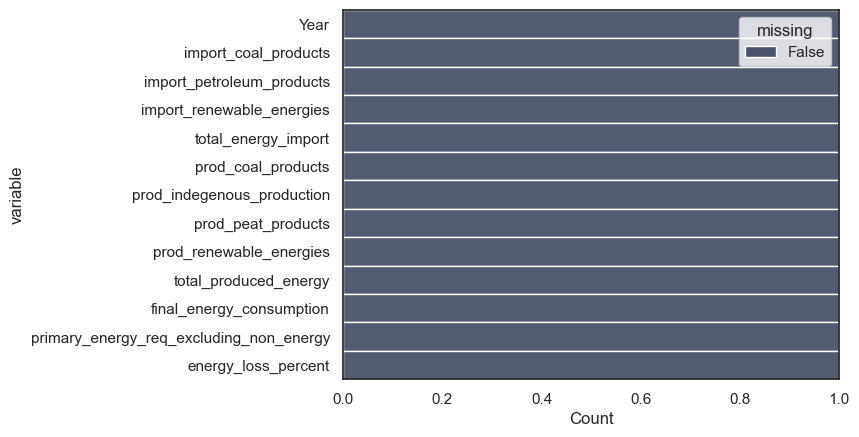

In [602]:
check_missing_val(ie_energy_summary_df)

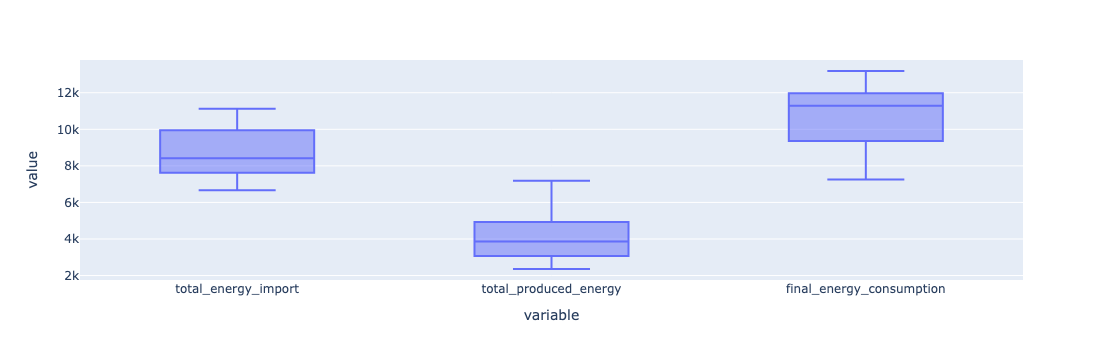

In [622]:
fig = px.box(ie_energy_summary_df[['total_energy_import', 'total_produced_energy', 'final_energy_consumption']])
fig.show()

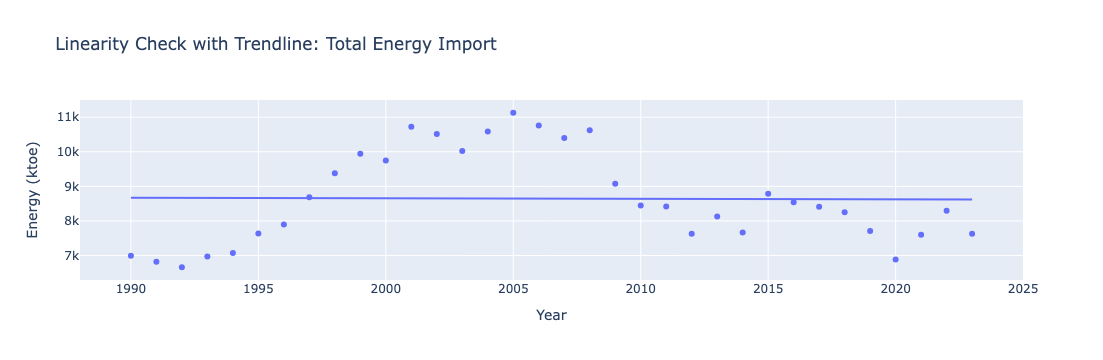

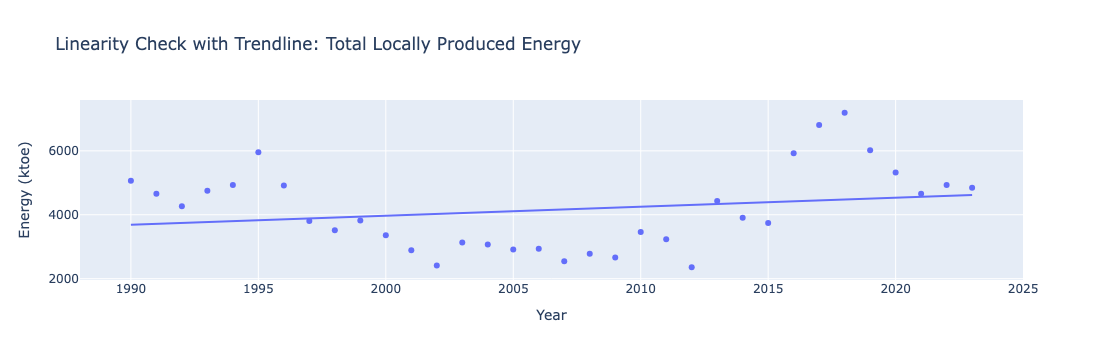

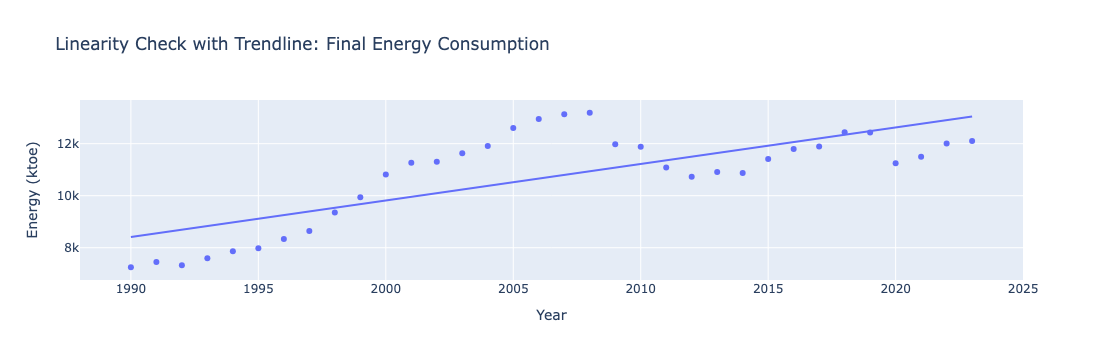

In [679]:
fig = px.scatter(
    ie_energy_summary_df,
    x='Year',
    y='total_energy_import',
    trendline='ols',  # Ordinary Least Squares (linear regression)
    title='Linearity Check with Trendline: Total Energy Import',
    labels={
        'total_energy_import': 'Energy (ktoe)'
    }
)
fig.show()

fig = px.scatter(
    ie_energy_summary_df,
    x='Year',
    y='total_produced_energy',
    trendline='ols',  # Ordinary Least Squares (linear regression)
    title='Linearity Check with Trendline: Total Locally Produced Energy',
        labels={
        'total_produced_energy': 'Energy (ktoe)'
    }
)
fig.show()
fig = px.scatter(
    ie_energy_summary_df,
    x='Year',
    y='final_energy_consumption',
    trendline='ols',  # Ordinary Least Squares (linear regression)
    title='Linearity Check with Trendline: Final Energy Consumption',
    labels={
        'final_energy_consumption': 'Energy (ktoe)'
    }
)
fig.show()

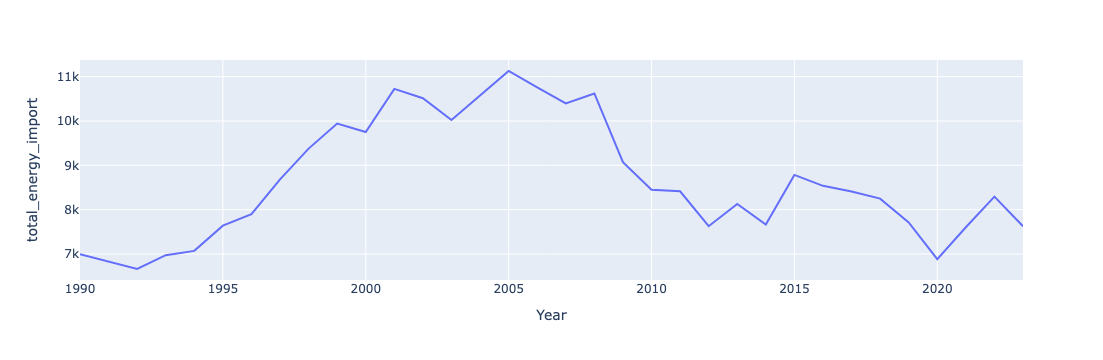

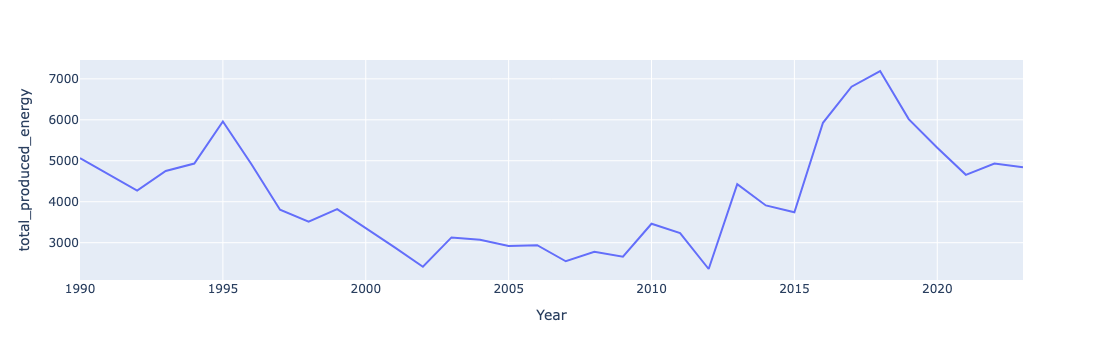

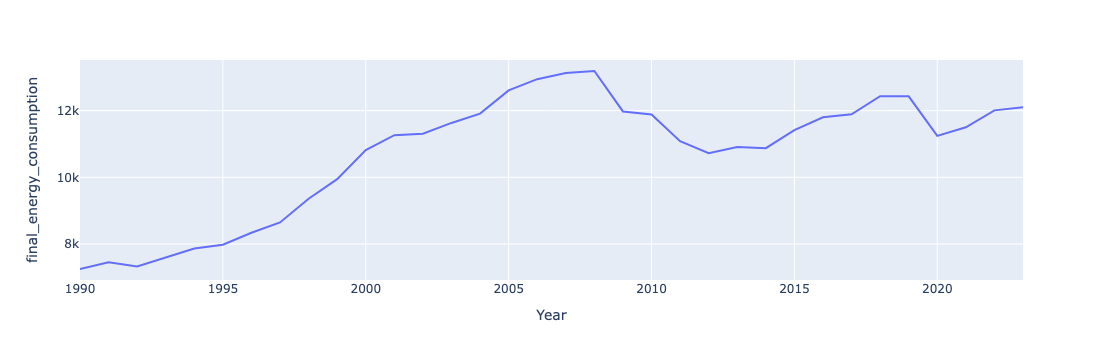

In [707]:
fig = px.line(ie_energy_summary_df, x='Year', y='total_energy_import')
fig.show()

fig = px.line(ie_energy_summary_df, x='Year', y='total_produced_energy')
fig.show()

fig = px.line(ie_energy_summary_df, x='Year', y='final_energy_consumption')
fig.show()